# K-Means Book Clustering

Book-level clustering using PCA features only.

In [1]:
from __future__ import annotations

import re
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display
from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score

K_VALUES = [25, 50, 75, 100, 125, 150]
FINAL_K = 100
RUN_EVALUATION = True
RUN_FINAL_MODEL = True
RANDOM_STATE = 42
SILHOUETTE_SAMPLE_SIZE = 10000
SILHOUETTE_FALLBACK_SAMPLE_SIZE = 5000


def find_project_root() -> Path:
    current = Path.cwd().resolve()
    for path in [current, *current.parents]:
        if (path / "data" / "features" / "master_feature_matrix.parquet").exists():
            return path
    raise FileNotFoundError("Could not find project root from current working directory.")


PROJECT_ROOT = find_project_root()
FEATURE_MATRIX_PATH = PROJECT_ROOT / "data" / "features" / "master_feature_matrix.parquet"
METADATA_PATH = PROJECT_ROOT / "data" / "processed" / "books_master.parquet"
OUTPUT_DIR = PROJECT_ROOT / "data" / "outputs" / "clustering"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Output dir: {OUTPUT_DIR}")

Project root: /home/nakato/projects/BigBook
Output dir: /home/nakato/projects/BigBook/data/outputs/clustering


In [2]:
GENRE_COLUMNS = {
    "genre_fantasy": "fantasy",
    "genre_mystery": "mystery",
    "genre_history": "history",
    "genre_ya": "young_adult",
    "genre_romance": "romance",
}
METADATA_COLUMNS = [
    "book_id",
    "title",
    "genres",
    "average_rating",
    "ratings_count",
    "language_code",
    "publication_year",
]
TITLE_STOPWORDS = {
    "the", "and", "for", "with", "from", "this", "that", "book", "books",
    "novel", "vol", "volume", "series", "edition", "part", "one", "two",
    "three", "four", "five", "six", "seven", "eight", "nine", "ten",
}


def pc_sort_key(column: str) -> int:
    match = re.fullmatch(r"pc_(\d+)", str(column))
    if not match:
        raise ValueError(f"Invalid PCA column name: {column}")
    return int(match.group(1))


def load_book_vectors(path: Path) -> tuple[pd.DataFrame, np.ndarray, list[str]]:
    df = pd.read_parquet(path)
    if "book_id" not in df.columns:
        raise ValueError("Feature matrix is missing book_id.")

    pc_cols = sorted(
        [column for column in df.columns if re.fullmatch(r"pc_\d+", str(column))],
        key=pc_sort_key,
    )
    if not pc_cols:
        raise ValueError("Feature matrix has no pc_* columns.")

    if df["book_id"].isna().any():
        raise ValueError("Feature matrix contains missing book_id values.")
    if df["book_id"].duplicated().any():
        raise ValueError("Feature matrix contains duplicated book_id values.")

    ids = df[["book_id"]].copy()
    ids["book_id"] = ids["book_id"].astype(str)
    X = df[pc_cols].to_numpy(dtype=np.float32)
    if np.isnan(X).any():
        raise ValueError("PCA feature matrix contains missing values.")
    if not np.isfinite(X).all():
        raise ValueError("PCA feature matrix contains infinite values.")
    return ids, X, pc_cols


def make_kmeans(k: int) -> KMeans:
    return KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")


def save_and_display_plot(path: Path) -> None:
    plt.savefig(path, dpi=150)
    plt.close()
    display(Image(filename=str(path)))


def derive_genres(metadata: pd.DataFrame) -> pd.DataFrame:
    available = [column for column in GENRE_COLUMNS if column in metadata.columns]
    if not available:
        return metadata

    metadata = metadata.copy()

    def join_genres(row: pd.Series) -> str:
        labels = [
            GENRE_COLUMNS[column]
            for column in available
            if pd.notna(row[column]) and int(row[column]) == 1
        ]
        return "|".join(labels)

    metadata["genres"] = metadata[available].apply(join_genres, axis=1)
    return metadata


def load_metadata() -> pd.DataFrame | None:
    if not METADATA_PATH.exists():
        return None

    metadata = pd.read_parquet(METADATA_PATH)
    if "book_id" not in metadata.columns:
        return None

    metadata = metadata.copy()
    metadata["book_id"] = metadata["book_id"].astype(str)
    metadata = derive_genres(metadata)
    keep = [column for column in METADATA_COLUMNS if column in metadata.columns]
    return metadata[keep].drop_duplicates("book_id")


book_ids, X, pc_cols = load_book_vectors(FEATURE_MATRIX_PATH)
print(f"Rows: {len(book_ids):,}")
print(f"PCA features: {len(pc_cols)} ({pc_cols[0]} to {pc_cols[-1]})")
print(f"Missing PCA values: {int(np.isnan(X).sum())}")
print(f"Duplicated book_id values: {int(book_ids['book_id'].duplicated().sum())}")

Rows: 108,227
PCA features: 173 (pc_0 to pc_172)
Missing PCA values: 0
Duplicated book_id values: 0


Evaluating K=25...


K=25 done in 1.5s
Evaluating K=50...
K=50 done in 2.1s
Evaluating K=75...
K=75 done in 3.0s
Evaluating K=100...
K=100 done in 4.0s
Evaluating K=125...
K=125 done in 6.1s
Evaluating K=150...
K=150 done in 6.4s
Saved /home/nakato/projects/BigBook/data/outputs/clustering/kmeans_k_evaluation.csv
K evaluation metrics


,k,inertia,silhouette,davies_bouldin,calinski_harabasz,min_cluster_size,max_cluster_size,mean_cluster_size,median_cluster_size
0,25,161294.3125,0.0954,2.3969,3591.8392,428,10958,4329.0800,3930.0
1,50,140768.2656,0.0942,2.3431,2337.2417,17,6870,2164.5400,1684.0
2,75,130706.9062,0.0766,2.5541,1778.8821,9,4126,1443.0267,1161.0
3,100,125197.1172,0.0702,2.7049,1435.9321,7,3147,1082.2700,906.5
4,125,121308.1016,0.0645,2.7903,1210.8581,7,2391,865.8160,746.0
5,150,117915.8203,0.0607,2.8406,1057.3118,2,2006,721.5133,689.0


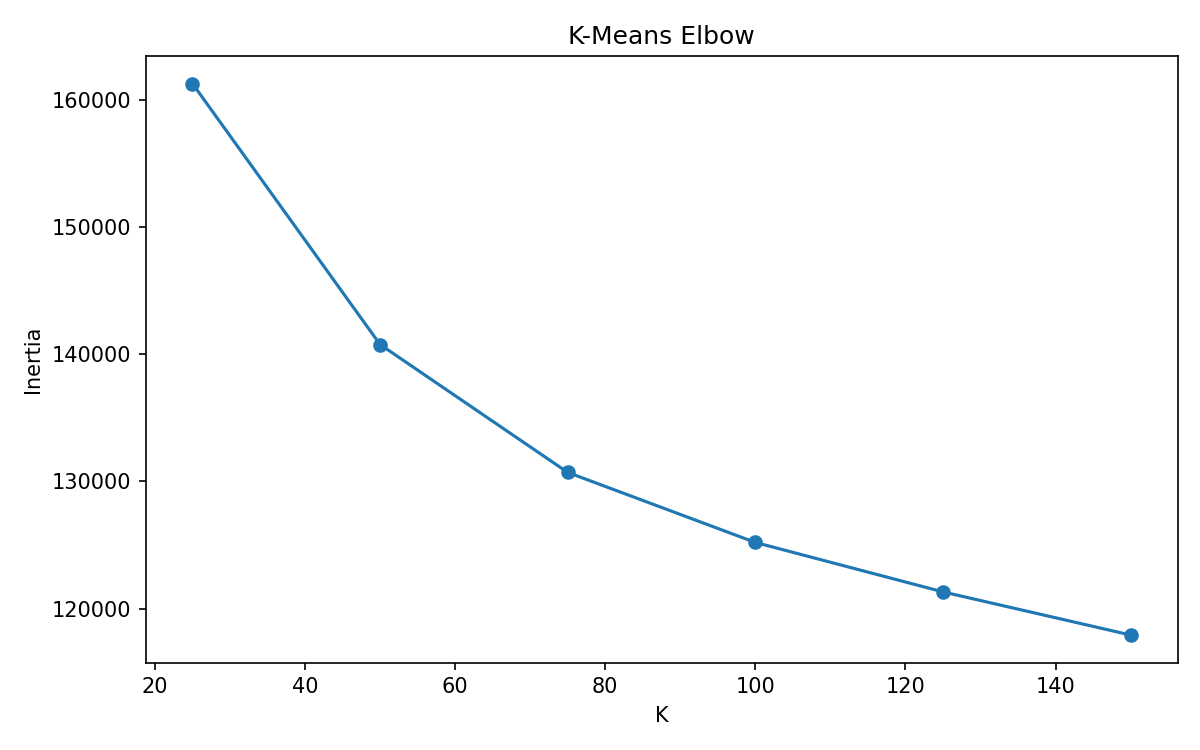

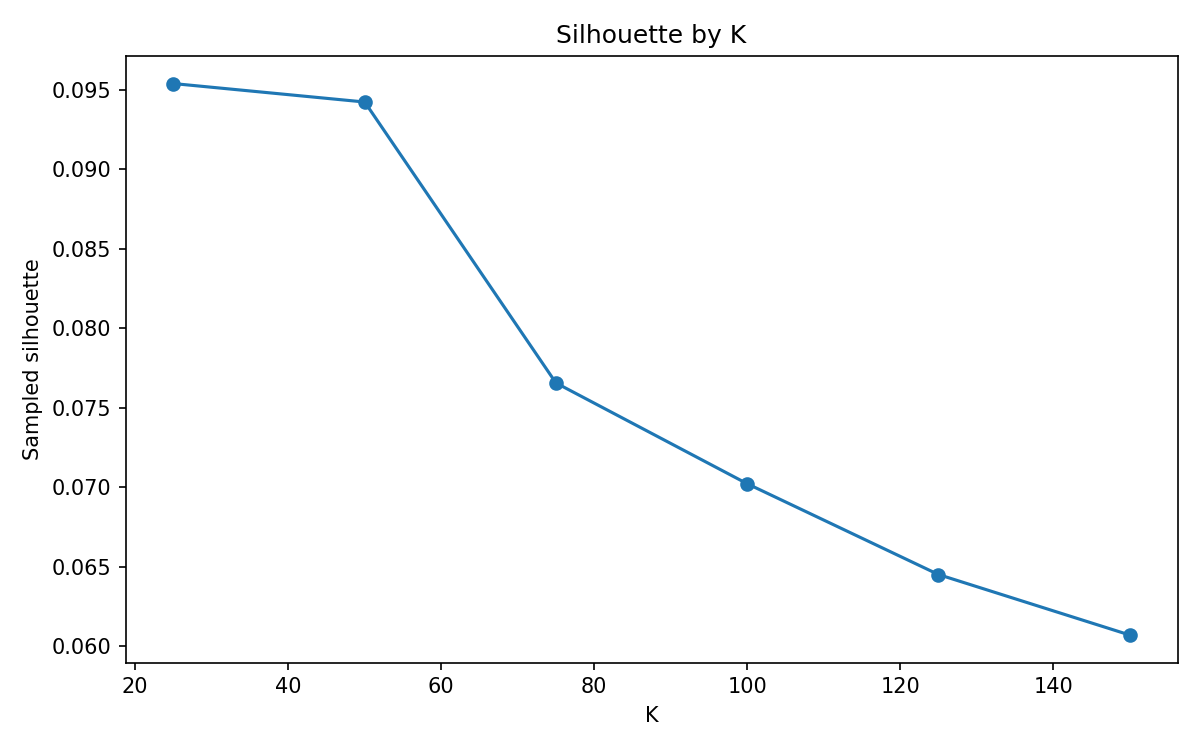

Saved evaluation plots


In [3]:
def cluster_size_stats(labels: np.ndarray) -> dict[str, float]:
    counts = pd.Series(labels).value_counts().sort_index()
    return {
        "min_cluster_size": int(counts.min()),
        "max_cluster_size": int(counts.max()),
        "mean_cluster_size": float(counts.mean()),
        "median_cluster_size": float(counts.median()),
    }


def sampled_silhouette(X: np.ndarray, labels: np.ndarray, sample_size: int) -> float:
    sample_size = min(sample_size, len(labels))
    try:
        return float(
            silhouette_score(
                X,
                labels,
                sample_size=sample_size,
                random_state=RANDOM_STATE,
            )
        )
    except Exception as exc:
        if sample_size <= SILHOUETTE_FALLBACK_SAMPLE_SIZE:
            raise
        print(f"Silhouette sample_size={sample_size} failed: {exc}")
        fallback_size = min(SILHOUETTE_FALLBACK_SAMPLE_SIZE, len(labels))
        print(f"Retrying silhouette with sample_size={fallback_size}")
        return float(
            silhouette_score(
                X,
                labels,
                sample_size=fallback_size,
                random_state=RANDOM_STATE,
            )
        )


def evaluate_k_values(X: np.ndarray, k_values: list[int]) -> pd.DataFrame:
    rows = []
    for k in k_values:
        start = time.time()
        print(f"Evaluating K={k}...")
        model = make_kmeans(k)
        labels = model.fit_predict(X)
        silhouette = sampled_silhouette(X, labels, SILHOUETTE_SAMPLE_SIZE)
        davies_bouldin = davies_bouldin_score(X, labels)
        calinski_harabasz = calinski_harabasz_score(X, labels)
        rows.append(
            {
                "k": k,
                "inertia": float(model.inertia_),
                "silhouette": silhouette,
                "davies_bouldin": float(davies_bouldin),
                "calinski_harabasz": float(calinski_harabasz),
                **cluster_size_stats(labels),
            }
        )
        print(f"K={k} done in {time.time() - start:.1f}s")

    evaluation = pd.DataFrame(rows)
    evaluation_path = OUTPUT_DIR / "kmeans_k_evaluation.csv"
    evaluation.to_csv(evaluation_path, index=False)
    print(f"Saved {evaluation_path}")
    print("K evaluation metrics")
    display(evaluation.round(4))
    return evaluation


def save_evaluation_plots(evaluation: pd.DataFrame) -> None:
    plt.figure(figsize=(8, 5))
    plt.plot(evaluation["k"], evaluation["inertia"], marker="o")
    plt.xlabel("K")
    plt.ylabel("Inertia")
    plt.title("K-Means Elbow")
    plt.tight_layout()
    save_and_display_plot(OUTPUT_DIR / "elbow_inertia.png")
    

    plt.figure(figsize=(8, 5))
    plt.plot(evaluation["k"], evaluation["silhouette"], marker="o")
    plt.xlabel("K")
    plt.ylabel("Sampled silhouette")
    plt.title("Silhouette by K")
    plt.tight_layout()
    save_and_display_plot(OUTPUT_DIR / "silhouette_by_k.png")
    print("Saved evaluation plots")


if RUN_EVALUATION:
    evaluation = evaluate_k_values(X, K_VALUES)
    save_evaluation_plots(evaluation)
else:
    evaluation = None
    print("RUN_EVALUATION=False; skipped K evaluation.")

Training final K-Means with K=100...


Saved /home/nakato/projects/BigBook/data/outputs/clustering/book_clusters_k100.parquet
Saved /home/nakato/projects/BigBook/data/outputs/clustering/kmeans_model_k100.joblib
Saved /home/nakato/projects/BigBook/data/outputs/clustering/kmeans_centroids_k100.npy


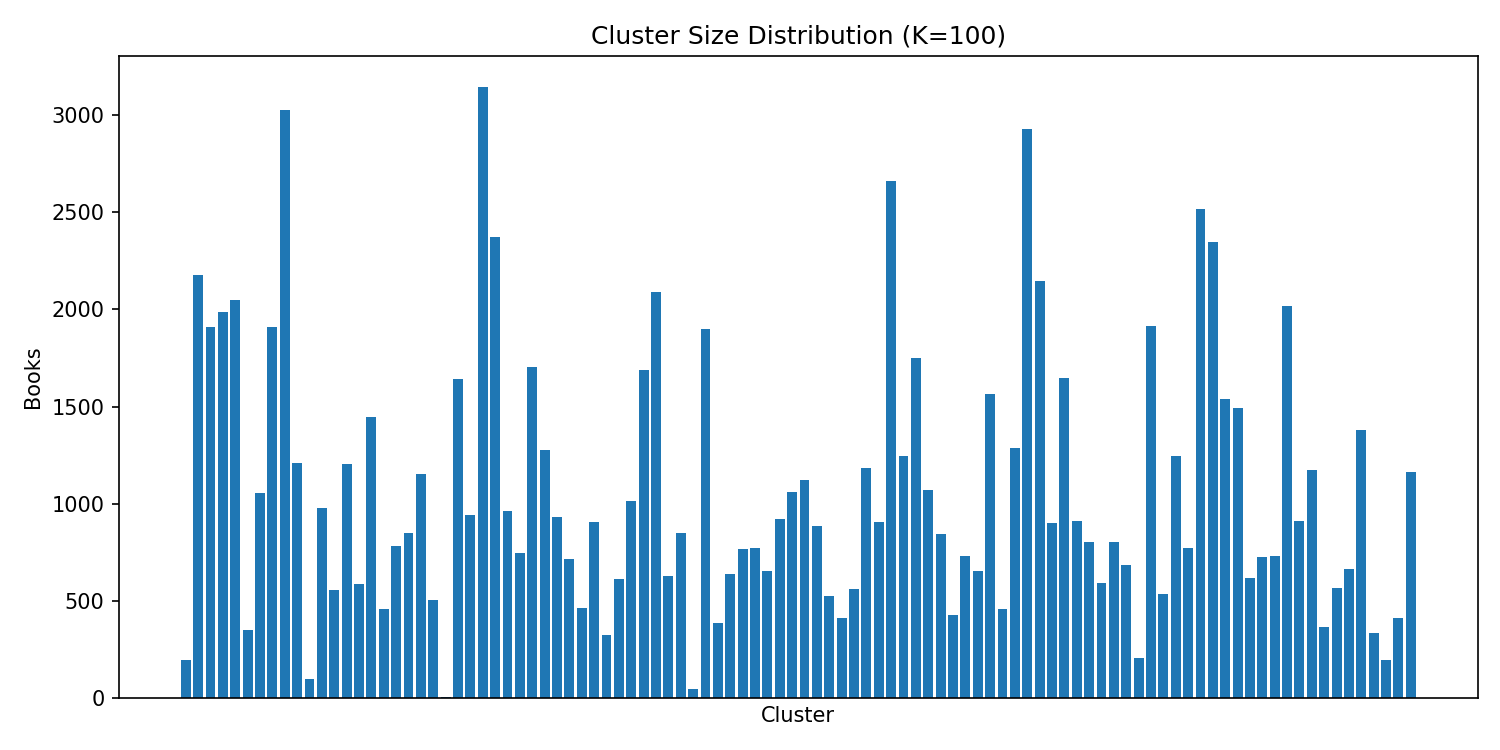

Saved /home/nakato/projects/BigBook/data/outputs/clustering/cluster_size_distribution_k100.png
Saved /home/nakato/projects/BigBook/data/outputs/clustering/cluster_summary_k100.csv
Cluster summary


,cluster,n_books,percentage
0,0,195,0.1802
1,1,2175,2.0097
2,2,1910,1.7648
3,3,1987,1.8360
4,4,2051,1.8951
...,...,...,...
95,95,1380,1.2751
96,96,334,0.3086
97,97,197,0.1820
98,98,411,0.3798


Saved /home/nakato/projects/BigBook/data/outputs/clustering/cluster_distance_stats_k100.csv
Worst clusters by p95 distance to centroid


,cluster,n_books,mean_distance_to_centroid,p95_distance_to_centroid,max_distance_to_centroid
21,21,7,4.4322,9.1591,10.9160
10,10,97,2.2140,3.9735,4.2551
41,41,47,2.0552,3.4544,4.2840
43,43,388,1.7028,2.2507,3.0681
92,92,367,1.5303,1.9981,2.9149
34,34,325,1.4516,1.9736,7.0918
16,16,461,1.4179,1.8108,3.4375
54,54,562,1.3622,1.7977,2.4621
97,97,197,1.3719,1.6719,1.8335
53,53,411,1.3267,1.6294,2.2484


Worst clusters by mean distance to centroid


,cluster,n_books,mean_distance_to_centroid,p95_distance_to_centroid,max_distance_to_centroid
21,21,7,4.4322,9.1591,10.9160
10,10,97,2.2140,3.9735,4.2551
41,41,47,2.0552,3.4544,4.2840
43,43,388,1.7028,2.2507,3.0681
92,92,367,1.5303,1.9981,2.9149
34,34,325,1.4516,1.9736,7.0918
16,16,461,1.4179,1.8108,3.4375
97,97,197,1.3719,1.6719,1.8335
54,54,562,1.3622,1.7977,2.4621
53,53,411,1.3267,1.6294,2.2484


Saved /home/nakato/projects/BigBook/data/outputs/clustering/cluster_examples_k100.csv
Saved /home/nakato/projects/BigBook/data/outputs/clustering/cluster_top_titles_terms_k100.csv
Top terms and representative titles by cluster


,cluster,top_title_terms,representative_titles,representative_book_ids
0,0,shifters|bear|bride|mystery|trilogy|brides|you|dark|king|heart|love|alpha,"Bear My Baby (Shifter Squad Six, #1) | Deliciously Mated (Ouachita Mountain Shifters, #1) | A Jaguar's Touch (Awakening Pride, #5) | Kra...",28379529|26861825|24972086|28803499|21863551|16131815|29404904|27109445|25739380|26232823
1,1,mystery|murder|dead|girl|jack|you|death|inspector|dark|mysteries|stone|reacher,"Eleven (Brandon Fisher FBI, #1) | Waiting for Wednesday (Frieda Klein, #3) | Live to Tell (Live to Tell #1) | The Fixer (Mort Grant, #1)...",13026005|17987216|6696296|20456068|13261123|20500886|13498900|17910156|18134782|8484321
2,2,love|you|boys|hana|over|brothers|flowers|his|billionaire|kimi|christmas|family,"Conquer Your Love (Surrender Your Love, #2) | Surrender Your Love (Surrender Your Love, #1) | Surrender to Sultry (Sultry Springs, #3) |...",17616120|17616105|17396178|18243678|16043810|2205321|17903637|16104077|9773090|17369254
3,3,life|story|world|war|american|history|memoir|girl|who|true|how|man,"The Midwife's Revolt (The Midwife Series, #1) | Z: A Novel of Zelda Fitzgerald | The Merchant's Daughter (Hagenheim, #2) | Running the R...",24961498|16002030|10742462|14569046|2062048|16074560|16130405|15848920|17829483|15759307
4,4,you|girl|all|divergent|delirium|girls|last|sky|life|love|secret|universe,"Mortality (The Hitchhiker Strain, #1) | Over You | Down to the Bone | Summer State of Mind (Whispering Pines, #2) | By Any Other Name | ...",16282078|16074995|1242745|18295805|16275210|13425135|13409474|14432989|21472663|16101138
5,5,dark|death|love|trilogy|blood|vampire|pack|dragon|chronicles|mystery|redwood|changeling,"Unforgiven (The Forbidden Bond, #2) | An Unlucky Moon (Dante's Circle, #3) | One Bite (Blood Prince, #2) | Charred Tears (Heart of Fire,...",13506100|16033884|18190902|19087292|10599320|23109419|8680662|16004684|29406462|17826918
6,6,blood|chronicles|dark|dead|trilogy|vampire|potter|harry|witch|discworld|saga|fire,"To Kill a Warlock (Dulcie O'Neil, #1) | Wrong Side of Dead (Dreg City, #4) | Avenger (Halflings, #3) | Blood Kin (The Half-Light City, #...",8568032|11738898|15528075|12380008|15745166|4916989|10775870|6456850|6069739|107379
7,7,story|life|history|war|world|diary|america|house|american|time|great|true,Henry And June | Colored People | Born in Blood and Fire: A Concise History of Latin America | The Chelsea Whistle | Christmas Revels | ...,168425|320783|47632|109173|563224|135143|2485947|226743|3831|189572
8,8,love|you|brothers|christmas|broken|perfect|all|heart|billionaire|home|bad|sweet,"High Risk Love (The Risk Series #1) | Scorched (Frigid, #2) | Jade's Cowboy Crush (Sweet Montana Bride #2) | Foreplay (The Ivy Chronicle...",17829224|24075594|19442234|18278161|18743123|15711443|18158427|16164536|25158460|26875510
9,9,chronicles|vampire|dragonlance|tales|magic|dragon|lost|dark|hunter|blood|shadow|trilogy,"The Sword (The Sword, the Ring, and the Chalice, #1) | Tehanu (Earthsea Cycle, #4) | The Farthest Shore (Earthsea Cycle, #3) | Into the ...",58437|13654|776572|1249731|6632391|362060|449261|107390|529607|26576


In [4]:
def save_cluster_size_plot(labels: np.ndarray, k: int) -> None:
    counts = pd.Series(labels).value_counts().sort_index()
    plt.figure(figsize=(10, 5))
    plt.bar(counts.index.astype(str), counts.values)
    plt.xlabel("Cluster")
    plt.ylabel("Books")
    plt.title(f"Cluster Size Distribution (K={k})")
    plt.xticks([])
    plt.tight_layout()
    path = OUTPUT_DIR / f"cluster_size_distribution_k{k}.png"
    save_and_display_plot(path)
    print(f"Saved {path}")


def save_cluster_summary(assignments: pd.DataFrame, k: int) -> None:
    summary = (
        assignments["cluster"]
        .value_counts()
        .sort_index()
        .rename_axis("cluster")
        .reset_index(name="n_books")
    )
    summary["percentage"] = summary["n_books"] / len(assignments) * 100
    path = OUTPUT_DIR / f"cluster_summary_k{k}.csv"
    summary.to_csv(path, index=False)
    print(f"Saved {path}")
    print("Cluster summary")
    display(summary.round({"percentage": 4}))


def save_cluster_distance_stats(assignments: pd.DataFrame, k: int) -> None:
    stats = (
        assignments.groupby("cluster")["distance_to_centroid"]
        .agg(
            n_books="size",
            mean_distance_to_centroid="mean",
            p95_distance_to_centroid=lambda values: values.quantile(0.95),
            max_distance_to_centroid="max",
        )
        .reset_index()
    )
    path = OUTPUT_DIR / f"cluster_distance_stats_k{k}.csv"
    stats.to_csv(path, index=False)
    print(f"Saved {path}")
    print("Worst clusters by p95 distance to centroid")
    display(stats.sort_values("p95_distance_to_centroid", ascending=False).head(20).round(4))
    print("Worst clusters by mean distance to centroid")
    display(stats.sort_values("mean_distance_to_centroid", ascending=False).head(20).round(4))


def save_cluster_examples(assignments: pd.DataFrame, k: int) -> None:
    examples = (
        assignments.sort_values(["cluster", "distance_to_centroid"], kind="mergesort")
        .groupby("cluster", as_index=False)
        .head(10)
        [["cluster", "book_id", "distance_to_centroid"]]
    )
    metadata = load_metadata()
    if metadata is not None:
        examples = examples.merge(metadata, on="book_id", how="left")
        ordered = [
            "cluster",
            "book_id",
            "title",
            "genres",
            "average_rating",
            "ratings_count",
            "distance_to_centroid",
        ]
        examples = examples[[column for column in ordered if column in examples.columns]]

    path = OUTPUT_DIR / f"cluster_examples_k{k}.csv"
    examples.to_csv(path, index=False)
    print(f"Saved {path}")


def title_terms(titles: pd.Series, limit: int = 12) -> str:
    tokens = []
    for title in titles.dropna().astype(str):
        for token in re.findall(r"[a-zA-Z]{3,}", title.lower()):
            if token not in TITLE_STOPWORDS:
                tokens.append(token)
    if not tokens:
        return ""
    return "|".join(pd.Series(tokens).value_counts().head(limit).index.tolist())


def save_cluster_title_terms(assignments: pd.DataFrame, k: int) -> None:
    metadata = load_metadata()
    if metadata is None or "title" not in metadata.columns:
        base = assignments.sort_values(["cluster", "distance_to_centroid"], kind="mergesort")
        rows = []
        for cluster, group in base.groupby("cluster", sort=True):
            rows.append(
                {
                    "cluster": cluster,
                    "top_title_terms": "",
                    "representative_titles": "",
                    "representative_book_ids": "|".join(group["book_id"].head(10).astype(str)),
                }
            )
    else:
        merged = assignments.merge(metadata, on="book_id", how="left")
        rows = []
        for cluster, group in merged.groupby("cluster", sort=True):
            closest = group.sort_values("distance_to_centroid", kind="mergesort").head(10)
            rows.append(
                {
                    "cluster": cluster,
                    "top_title_terms": title_terms(group["title"]),
                    "representative_titles": " | ".join(closest["title"].dropna().astype(str)),
                    "representative_book_ids": "|".join(closest["book_id"].astype(str)),
                }
            )

    terms = pd.DataFrame(rows)
    path = OUTPUT_DIR / f"cluster_top_titles_terms_k{k}.csv"
    terms.to_csv(path, index=False)
    print(f"Saved {path}")
    print("Top terms and representative titles by cluster")
    with pd.option_context("display.max_rows", 120, "display.max_colwidth", 140):
        display(terms)


if RUN_FINAL_MODEL:
    k = FINAL_K
    print(f"Training final K-Means with K={k}...")
    final_model = make_kmeans(k)
    final_labels = final_model.fit_predict(X)
    centroids = final_model.cluster_centers_.astype(np.float32)
    distances = np.linalg.norm(X - centroids[final_labels], axis=1)

    assignments = book_ids.copy()
    assignments["cluster"] = final_labels.astype(np.int32)
    assignments["distance_to_centroid"] = distances.astype(np.float32)

    clusters_path = OUTPUT_DIR / f"book_clusters_k{k}.parquet"
    assignments[["book_id", "cluster"]].to_parquet(clusters_path, index=False)
    print(f"Saved {clusters_path}")

    model_path = OUTPUT_DIR / f"kmeans_model_k{k}.joblib"
    joblib.dump(final_model, model_path)
    print(f"Saved {model_path}")

    centroids_path = OUTPUT_DIR / f"kmeans_centroids_k{k}.npy"
    np.save(centroids_path, centroids)
    print(f"Saved {centroids_path}")

    save_cluster_size_plot(final_labels, k)
    save_cluster_summary(assignments, k)
    save_cluster_distance_stats(assignments, k)
    save_cluster_examples(assignments, k)
    save_cluster_title_terms(assignments, k)
else:
    print("RUN_FINAL_MODEL=False; skipped final model training.")